In [2]:
%matplotlib widget

## LCI Inversion

In [3]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

from showStitched import showStitchedModels

## Set acquisition parameters 

In [4]:
# Initialize forward modelling class

Freq = 9000
coilOrient = np.array(['H', 'V', 'P'])
coilSpacing = np.array([2, 4, 8])
nLayers = 3 # careful: nlay must be equal in 1Dfop and LC
height = 0

## 1. Create 1D forward operator class

In [5]:
class fop1d():
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]

    Returns
    -------
    Array [OP, IP]

    """  
    def __init__(self, Freq, coilOrient, coilSpacing, height):
        """ initialize class """
        
        self.Freq = Freq
        self.coilOrient = coilOrient
        self.coilSpacing = coilSpacing
        self.height = height
    
    def em1d(self, sgm, thk):
        # Source and receivers geometry [x, y, z]
        source    = [0, 0, -self.height]
        receivers = [self.coilSpacing, np.zeros(len(self.coilSpacing)), -self.height]
        # Depth and resistivity
        res_air = 1e6
        res = np.hstack((res_air, 1/sgm))
        depth = np.hstack((0, np.cumsum(thk)))
        # Empty array to store responses
        OUT = []

        if any(coilOrient == 'H'):

            H_Hs = ep.dipole(source, receivers, depth, res, self.Freq, ab = 66, xdirect=None, 
                              verb=0)*(2j * np.pi * self.Freq * mu_0) 
            H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = self.Freq,
                             ab = 66, verb=0)*(2j * np.pi * self.Freq * mu_0)   
            op = (H_Hs/H_Hp).imag.amp() 
            ip = (H_Hs/H_Hp).real.amp() 
            OUT.append([op, ip])

        if any(coilOrient == 'V'):
            V_Hs = ep.dipole(source, receivers, depth, res, self.Freq, ab =55, xdirect=None, 
                             verb=0)*(2j * np.pi * self.Freq * mu_0) 
            V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=self.Freq,ab=55, 
                             verb=0)*(2j * np.pi * self.Freq * mu_0)
            op = (V_Hs/V_Hp).imag.amp() 
            ip = (V_Hs/V_Hp).real.amp() 
            OUT.append([op, ip])

        if any(coilOrient == 'P'):
            # Maybe put 0.1m in receiver offset
            P_Hs = ep.dipole(source, receivers, depth, res, self.Freq, ab=46, xdirect=None, 
                             verb=0)*(2j * np.pi * self.Freq * mu_0) 
            P_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime= self.Freq,
                             ab=66, verb=0)*(2j * np.pi * self.Freq * mu_0) 
            op = (P_Hs/P_Hp).imag.amp() 
            ip = (P_Hs/P_Hp).real.amp() 

            OUT.append([op, ip])

        return np.array(OUT).ravel()        

In [6]:
# Initialize forward operator class

fop1d = fop1d(Freq, coilOrient, coilSpacing, height)

## 1. Create forward modelling class

In [7]:
# Class for 1D forward modelling

class FDEM1D(pg.frameworks.Modelling):
    """ Class forward modelling Frequency Domain EM data """
    def __init__(self, nLayers=nLayers):
        """ Initialize class and set survey configuration """
        self.nLayers = nLayers
        mesh = pg.meshtools.createMesh1DBlock(self.nLayers)
        super().__init__()
        self.setMesh(mesh)
        
    def response(self, mod):
        """ Compute response vector for a certain model [mod] 
        mod = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
        resp = fop1d.em1d(np.asarray(mod)[self.nLayers-1:self.nLayers*2-1],   # sigma
                       np.asarray(mod)[:self.nLayers-1]                  # thickness
                       )
        return resp
    
    def response_mt(self, mod, i=0):
        """Multi-threaded forward response."""
        return self.response(mod)
    
    def createJacobian(self, mod, dx=1e-8):
        """ compute Jacobian for a 1D model """
        resp = self.response(mod)
        n_rows = len(resp) # number of data values in data vector
        n_cols = len(mod) # number of model parameters
        J = self.jacobian() # we define first this as the jacobian
        J.resize(n_rows, n_cols)
        Jt = np.zeros((n_cols, n_rows))
        for j in range(n_cols):
            mod_plus_dx = mod.copy()
            mod_plus_dx[j] += dx
            Jt[j,:] = (self.response(mod_plus_dx) - resp)/dx # J.T in col j
        for i in range(n_rows):
            J[i] = Jt[:,i]
    
    def createDefaultStartModel(self, mod):
        """ create default start model 1D """
        model_0 = pg.Vector([2, 2, 20/1000, 20/1000, 20/1000])
        return model_0

## 2. Test forward operator

In [8]:
FOP = FDEM1D()

# model = [thickness_1, sigma_2, sigma_2]
model = np.array([2, 2, 20/1000, 30/1000, 40/1000])

a = FOP.response(model)

### Create a dataset of 10 1D positions with 4 layers

In [9]:
# Create the 1D models

pos = 10

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 10/1000
sigm_2 = 20/1000
sigm_3 = 40/1000
thk_1 = 1/5*x + 1
thk_2 = 2 - 1/7*x

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
models[:,1] = thk_2
models[:,2] = sigm_1
models[:,3] = sigm_2
models[:,4] = sigm_3


In [10]:
# Simulate data for each 1D model

data = []
for p in range(pos):
    data.append(FOP.response(models[p]))

## 3. Create LCModelling class
This class makes the full 2D model

In [11]:
class LCModelling(pg.frameworks.Modelling):
    """2D Laterally constrained (LC) modelling.

    2D Laterally constrained (LC) modelling based on BlockMatrices.
    """

    def __init__(self, fop, **kwargs):
        """Parameters: fop class ."""
        super(LCModelling, self).__init__()
        self._singleRegion = False
        self._fopTemplate = fop
        self._fopKwargs = kwargs
        self._fops1D = []
        self._mesh = None
        self._nSoundings = 0
        self._parPerSounding = 0
        self._jac = None
        self.soundingPos = None

    def setDataBasis(self, **kwargs):
        """Set homogeneous data basis.

        Set a common data basis to all forward operators.
        If you want individual you need to set them manually.
        """
        for f in self._fops1D:
            f.setDataBasis(**kwargs)

    def initModelSpace(self, nLayers):
        """Initialize model space."""
        for i, f in enumerate(self._fops1D):
            f.initModelSpace(nLayers)

    def createDefaultStartModel(self, models):
        """Create default starting model."""
        sm = pg.Vector()
        for i, f in enumerate(self._fops1D):
            sm = pg.cat(sm, f.createDefaultStartModel(models[i]))
        return sm

    def response(self, par):
        """Cut together forward responses of all soundings."""
        mods = np.asarray(par).reshape(self._nSoundings, self._parPerSounding)

        resp = pg.Vector(0)
        for i in range(self._nSoundings):
            r = self._fops1D[i].response(mods[i])
            # print("i:", i, mods[i], r)
            resp = pg.cat(resp, r)

        return resp

    def createJacobian(self, par):
        """Create Jacobian matrix by creating individual Jacobians."""
        mods = np.asarray(par).reshape(self._nSoundings, self._parPerSounding)

        for i in range(self._nSoundings):
            self._fops1D[i].createJacobian(mods[i])

    def createParametrization(self, nSoundings, nLayers=4, nPar=1):
        """Create LCI mesh and suitable constraints informations.

        Parameters
        ----------
        nLayers : int
            Numbers of depth layers

        nSoundings : int
            Numbers of 1D measurements to laterally constrain

        nPar : int
            Numbers of independent parameter types,
            e.g., nPar = 1 for VES (invert for resisitivies),
            nPar = 2 for VESC (invert for resisitivies and phases)
        """
        nCols = (nPar+1) * nLayers - 1  # fail for VES-C
        self._parPerSounding = nCols
        self._nSoundings = nSoundings

        self._mesh = pg.meshtools.createMesh2D(range(nCols + 1),
                                               range(nSoundings + 1))
        self._mesh.rotate(pg.RVector3(0, 0, -np.pi/2))

        cm = np.ones(nCols * nSoundings) * 1

        if not self._singleRegion:
            for i in range(nSoundings):
                for j in range(nPar):
                    cm[i * self._parPerSounding + (j+1) * nLayers-1:
                       i * self._parPerSounding + (j+2) * nLayers-1] += (j+1)

        self._mesh.setCellMarkers(cm)
        self.setMesh(self._mesh)

        pID = self.regionManager().paraDomain().cellMarkers()
        cID = [c.id() for c in self._mesh.cells()]
        # print(np.array(pID))
        # print(np.array(cID))
        # print(self.parameterCount)
        perm = [0]*self.parameterCount
        for i in range(len(perm)):
            perm[pID[i]] = cID[i]

        # print(perm)
        self.regionManager().permuteParameterMarker(perm)
        # print(self.regionManager().paraDomain().cellMarkers())

    def initJacobian(self, dataVals, nLayers, nPar=None):
        """Initialize Jacobian matrix.

        Parameters
        ----------
        dataVals : ndarray | RMatrix | list
            Data values of size (nSounding x Data per sounding).
            All data per sounding need to be equal in length.
            If they don't fit into a matrix use list of sounding data.
        """
        nSoundings = len(dataVals)

        if nPar is None:
            # TODO get nPar Infos from fop._fopTemplate
            nPar = 1

        self.createParametrization(nSoundings, nLayers=nLayers, nPar=nPar)

        if self._jac is not None:
            self._jac.clear()
        else:
            self._jac = pg.matrix.BlockMatrix()

        self.fops1D = []
        nData = 0

        for i in range(nSoundings):
          #  print(i)
            kwargs = {}
            for key, val in self._fopKwargs.items():
                if hasattr(val, '__iter__'):
                  #  if len(val) == nSoundings:
                    kwargs[key] = val[i] # what is this for
                else:
                    kwargs[key] = val

            f = None
            if issubclass(self._fopTemplate, pg.frameworks.Modelling):
                f = self._fopTemplate(**kwargs)
            else:
                f = type(self._fopTemplate)(self.verbose, **kwargs)

            f.setMultiThreadJacobian(self._parPerSounding)

            self._fops1D.append(f)

            nID = self._jac.addMatrix(f.jacobian())
           # print(f.jacobian())
            self._jac.addMatrixEntry(nID, nData, self._parPerSounding * i)
            nData += len(dataVals[i])
           # print(self._jac)

        self._jac.recalcMatrixSize()
        # print("Jacobian size:", self._jac.rows(), self._jac.cols(), nData)
        self.setJacobian(self._jac)


    def drawModel(self, ax, model, **kwargs):
        """Draw models as stitched 1D model section."""
        mods = np.asarray(model).reshape(self._nSoundings,
                                         self._parPerSounding)
        pg.viewer.mpl.showStitchedModels(mods, ax=ax, useMesh=True,
                                         x=self.soundingPos,
                                         **kwargs)

In [12]:
LC = LCModelling(FDEM1D)
LC.createParametrization(pos, nLayers=3, nPar=1)
LC.initJacobian(dataVals=data, nLayers=3, nPar=1)
m0=LC.createDefaultStartModel(models)


<AxesSubplot:>

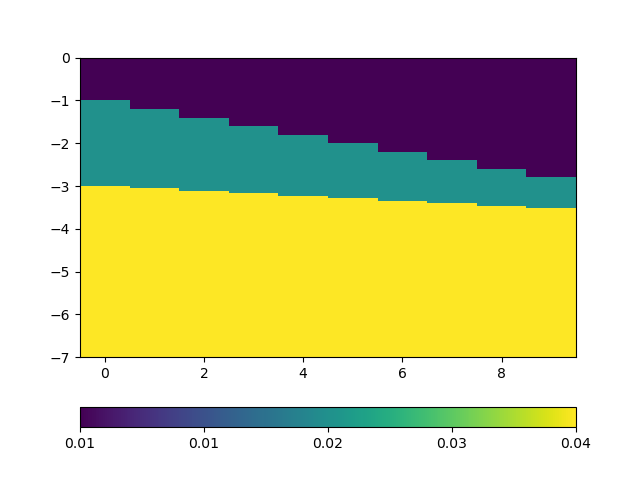

In [13]:
fig, ax = plt.subplots()

showStitchedModels(models, ax, zMax=7) 


## 4. Create Inversion class

In [46]:
inv = pg.Inversion(LC)
data_true = np.array(data).ravel()
relativeError = np.ones_like(data_true)*1e-3

In [47]:
models_est = inv.run(data_true, relativeError, startModel=m0, verbose=False)

01/02/24 - 18:02:24 - pyGIMLi - INFO - Starting model set from given array. 50 [2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02, 2.0, 2.0, 0.02, 0.02, 0.02]


<AxesSubplot:>

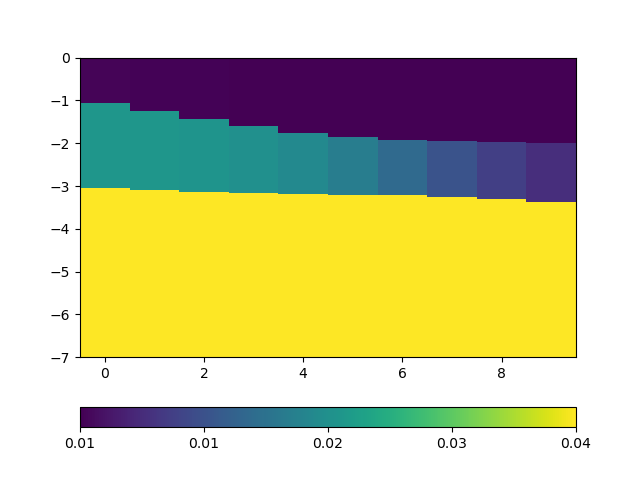

In [48]:
fig, ax = plt.subplots()

showStitchedModels(np.reshape(models_est, np.shape(models)), ax, zMax=7) 